In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3

pd.options.mode.chained_assignment = None 

# --- 1. CODESPACES PATHING ---
PROJECT_ROOT = "/workspaces/pienza"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
DUMP_DIR = os.path.join(DATA_DIR, "dumped_files")
DB_PATH = os.path.join(DATA_DIR, "pienza.db")

# --- 2. CONNECTIVITY ---
if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 3. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print(f"✅ SOP Ready: Writing to {DUMP_DIR}")

✅ Database found: /workspaces/pienza/data/pienza.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).
✅ SOP Ready: Writing to /workspaces/pienza/data/dumped_files


In [2]:
# ==============================================================================
# CELL 1: THE MASTER VIEW INGESTION & COLUMN INVENTORY (ORIGINAL ORDER)
# ==============================================================================

print("⏳ Loading the Master Analytical View (v_ML_Supervised)...")

query = "SELECT * FROM v_ML_Supervised"

try:
    # 1. Ingest Data
    df_grand = pd.read_sql(query, db_engine)

    # Hygiene: Drop duplicate columns
    df_grand = df_grand.loc[:, ~df_grand.columns.duplicated()]

    print(f"✅ Master View Loaded. Shape: {df_grand.shape}")

    # 2. Full Column Inventory (Preserving View Order)
    print("\n📋 FULL COLUMN INVENTORY (Original Database Order):")
    print("-" * 60)

    # We grab the columns exactly as they come from the DB
    cols = df_grand.columns.tolist()

    # Print in a clean, numbered list
    for i, col in enumerate(cols):
        # We print the type as well for extra context
        dtype = df_grand[col].dtype
        print(f"{i+1:03d}. {col:<40} ({dtype})")

    print("-" * 60)

except Exception as e:
    print(f"🔴 SQL Error: {e}")

⏳ Loading the Master Analytical View (v_ML_Supervised)...
✅ Master View Loaded. Shape: (4765, 104)

📋 FULL COLUMN INVENTORY (Original Database Order):
------------------------------------------------------------
001. offer_id                                 (object)
002. session_fk                               (object)
003. ocr_fk                                   (object)
004. image_content_hash                       (object)
005. offer_timestamp                          (object)
006. upfront_fare                             (float64)
007. time_to_pickup_sec                       (float64)
008. dist_to_pickup_km                        (float64)
009. est_trip_time_sec                        (float64)
010. est_trip_dist_km                         (float64)
011. pickup_address                           (object)
012. dropoff_address                          (object)
013. pickup_lat                               (float64)
014. pickup_lon                               (float64)
015. dropof

In [3]:
# ==============================================================================
# CELL 2: THE INITIAL PURGE (DROPPING NOISE & LEAKAGE)
# ==============================================================================

# Define the Kill List based on strategic criteria
cols_to_drop = [
    # --- 1. Text & Metadata (Non-Numeric / ID pointers) ---
    'comment_1', 'comment_2', 'special_note_raw',
    'offer_id', 'feature_id', 'session_fk', 'ocr_fk', 'image_content_hash',
    'dropoff_address', 'dropoff_ambiguity', 'dropoff_hdbscan_name',
    'pickup_ambiguity',

    # --- 2. Data Leakage (EDA Features - Future Knowledge) ---
    'eph_complete_EDA', 'eph_complete_index_EDA', 'eph_complete_label_EDA',
    'eph_realized_EDA', 'eph_realized_index_EDA', 'eph_realized_label_EDA',
    'is_spread_downgrade_EDA', 'is_total_cycle_downgrade_EDA',
    'traffic_volatility_index_eda', # Only known after trip completion

    # --- 3. Low Variance / Irrelevant Signals (Strategic Exclusion) ---
    'is_exclusive', 'is_vip', 'is_teens', 'is_identity_verified', # Rare/Noise
    'is_imputed', 'record_status_fk', 'interpolation_quality_fk', # Admin flags
    'rider_star_rating', 'rider_trip_count' # Architect's Domain Override (Cognitive Blindness)
]

print(f"📉 Initiating Purge of {len(cols_to_drop)} columns...")

# Execute Drop
df_grand = df_grand.drop(columns=cols_to_drop, errors='ignore')

# Verification
print(f"✅ Purge Complete. New Shape: {df_grand.shape}")
print("-" * 60)
print("Remaining Columns for Analysis:")
print(sorted(df_grand.columns.tolist()))

📉 Initiating Purge of 30 columns...
✅ Purge Complete. New Shape: (4765, 74)
------------------------------------------------------------
Remaining Columns for Analysis:
['consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings', 'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio', 'day_of_week', 'day_type', 'dispatch_lead_time_sec', 'dist_to_pickup_km', 'driver_state_at_request_fk', 'dropoff_h3_hex_id', 'dropoff_hdbscan_id', 'dropoff_lat', 'dropoff_lon', 'dropoff_polygon_id', 'dropoff_polygon_name', 'eph_complete_ML', 'eph_complete_index_ML', 'eph_complete_label_ML', 'eph_direct', 'eph_direct_index', 'eph_direct_label', 'eph_operational', 'eph_operational_index', 'eph_operational_label', 'eph_realized_ML', 'eph_realized_index_ML', 'eph_realized_label_ML', 'est_trip_dist_km', 'est_trip_time_sec', 'heuristic_flag_context', 'historical_rolling_avg_traffic_index', 'home_vector_alignment_score', 'inferred_agent_bearing', 'inferred_agent_lat', 'inferred_age

In [4]:
# ==============================================================================
# CELL 3: MATRIX REFRESH (PRE-CORRELATION CHECK)
# ==============================================================================

# 1. Strategic Drop List
# Since the Variance Filter found 0 issues, this list is currently empty.
# We keep the logic in place in case manual drops are required in future iterations.
cols_to_drop = []

if cols_to_drop:
    print(f"✂️ Dropping specific features: {cols_to_drop}...")
    df_grand = df_grand.drop(columns=cols_to_drop, errors='ignore')
else:
    print("✅ No additional features marked for deletion based on Variance.")

# 2. Re-Define X_analysis (The Feature Matrix)
# We must strictly exclude Targets and IDs so the Correlation Matrix focuses ONLY on Features.
numeric_cols = df_grand.select_dtypes(include=[np.number]).columns.tolist()

# Define columns to EXCLUDE from the correlation analysis (Targets & Metadata)
target_and_meta_cols = [
    'offer_id',
    'reason_primary_fk',         # TARGET (The answer key)
    'offer_action_fk',           # Target Proxy
    'outcome_fk',                # Future Outcome
    'post_offer_status_fk',      # Future Outcome
    'dropoff_hdbscan_id',        # Geo ID (Categorical)
    'dropoff_polygon_id'         # Geo ID (Categorical)
]

# Filter: Keep only numeric columns that are NOT in the exclusion list
X_analysis_cols = [col for col in numeric_cols if col not in target_and_meta_cols]
X_analysis = df_grand[X_analysis_cols]

print(f"✅ Matrix Refreshed. Current Feature Count: {X_analysis.shape[1]}")
print("   -> Targets and Metadata excluded to ensure clean Feature Correlation.")
print("\n--- READY FOR CORRELATION ANALYSIS ---")

✅ No additional features marked for deletion based on Variance.
✅ Matrix Refreshed. Current Feature Count: 53
   -> Targets and Metadata excluded to ensure clean Feature Correlation.

--- READY FOR CORRELATION ANALYSIS ---


⏳ Calculating Correlation Matrix on Feature Set...


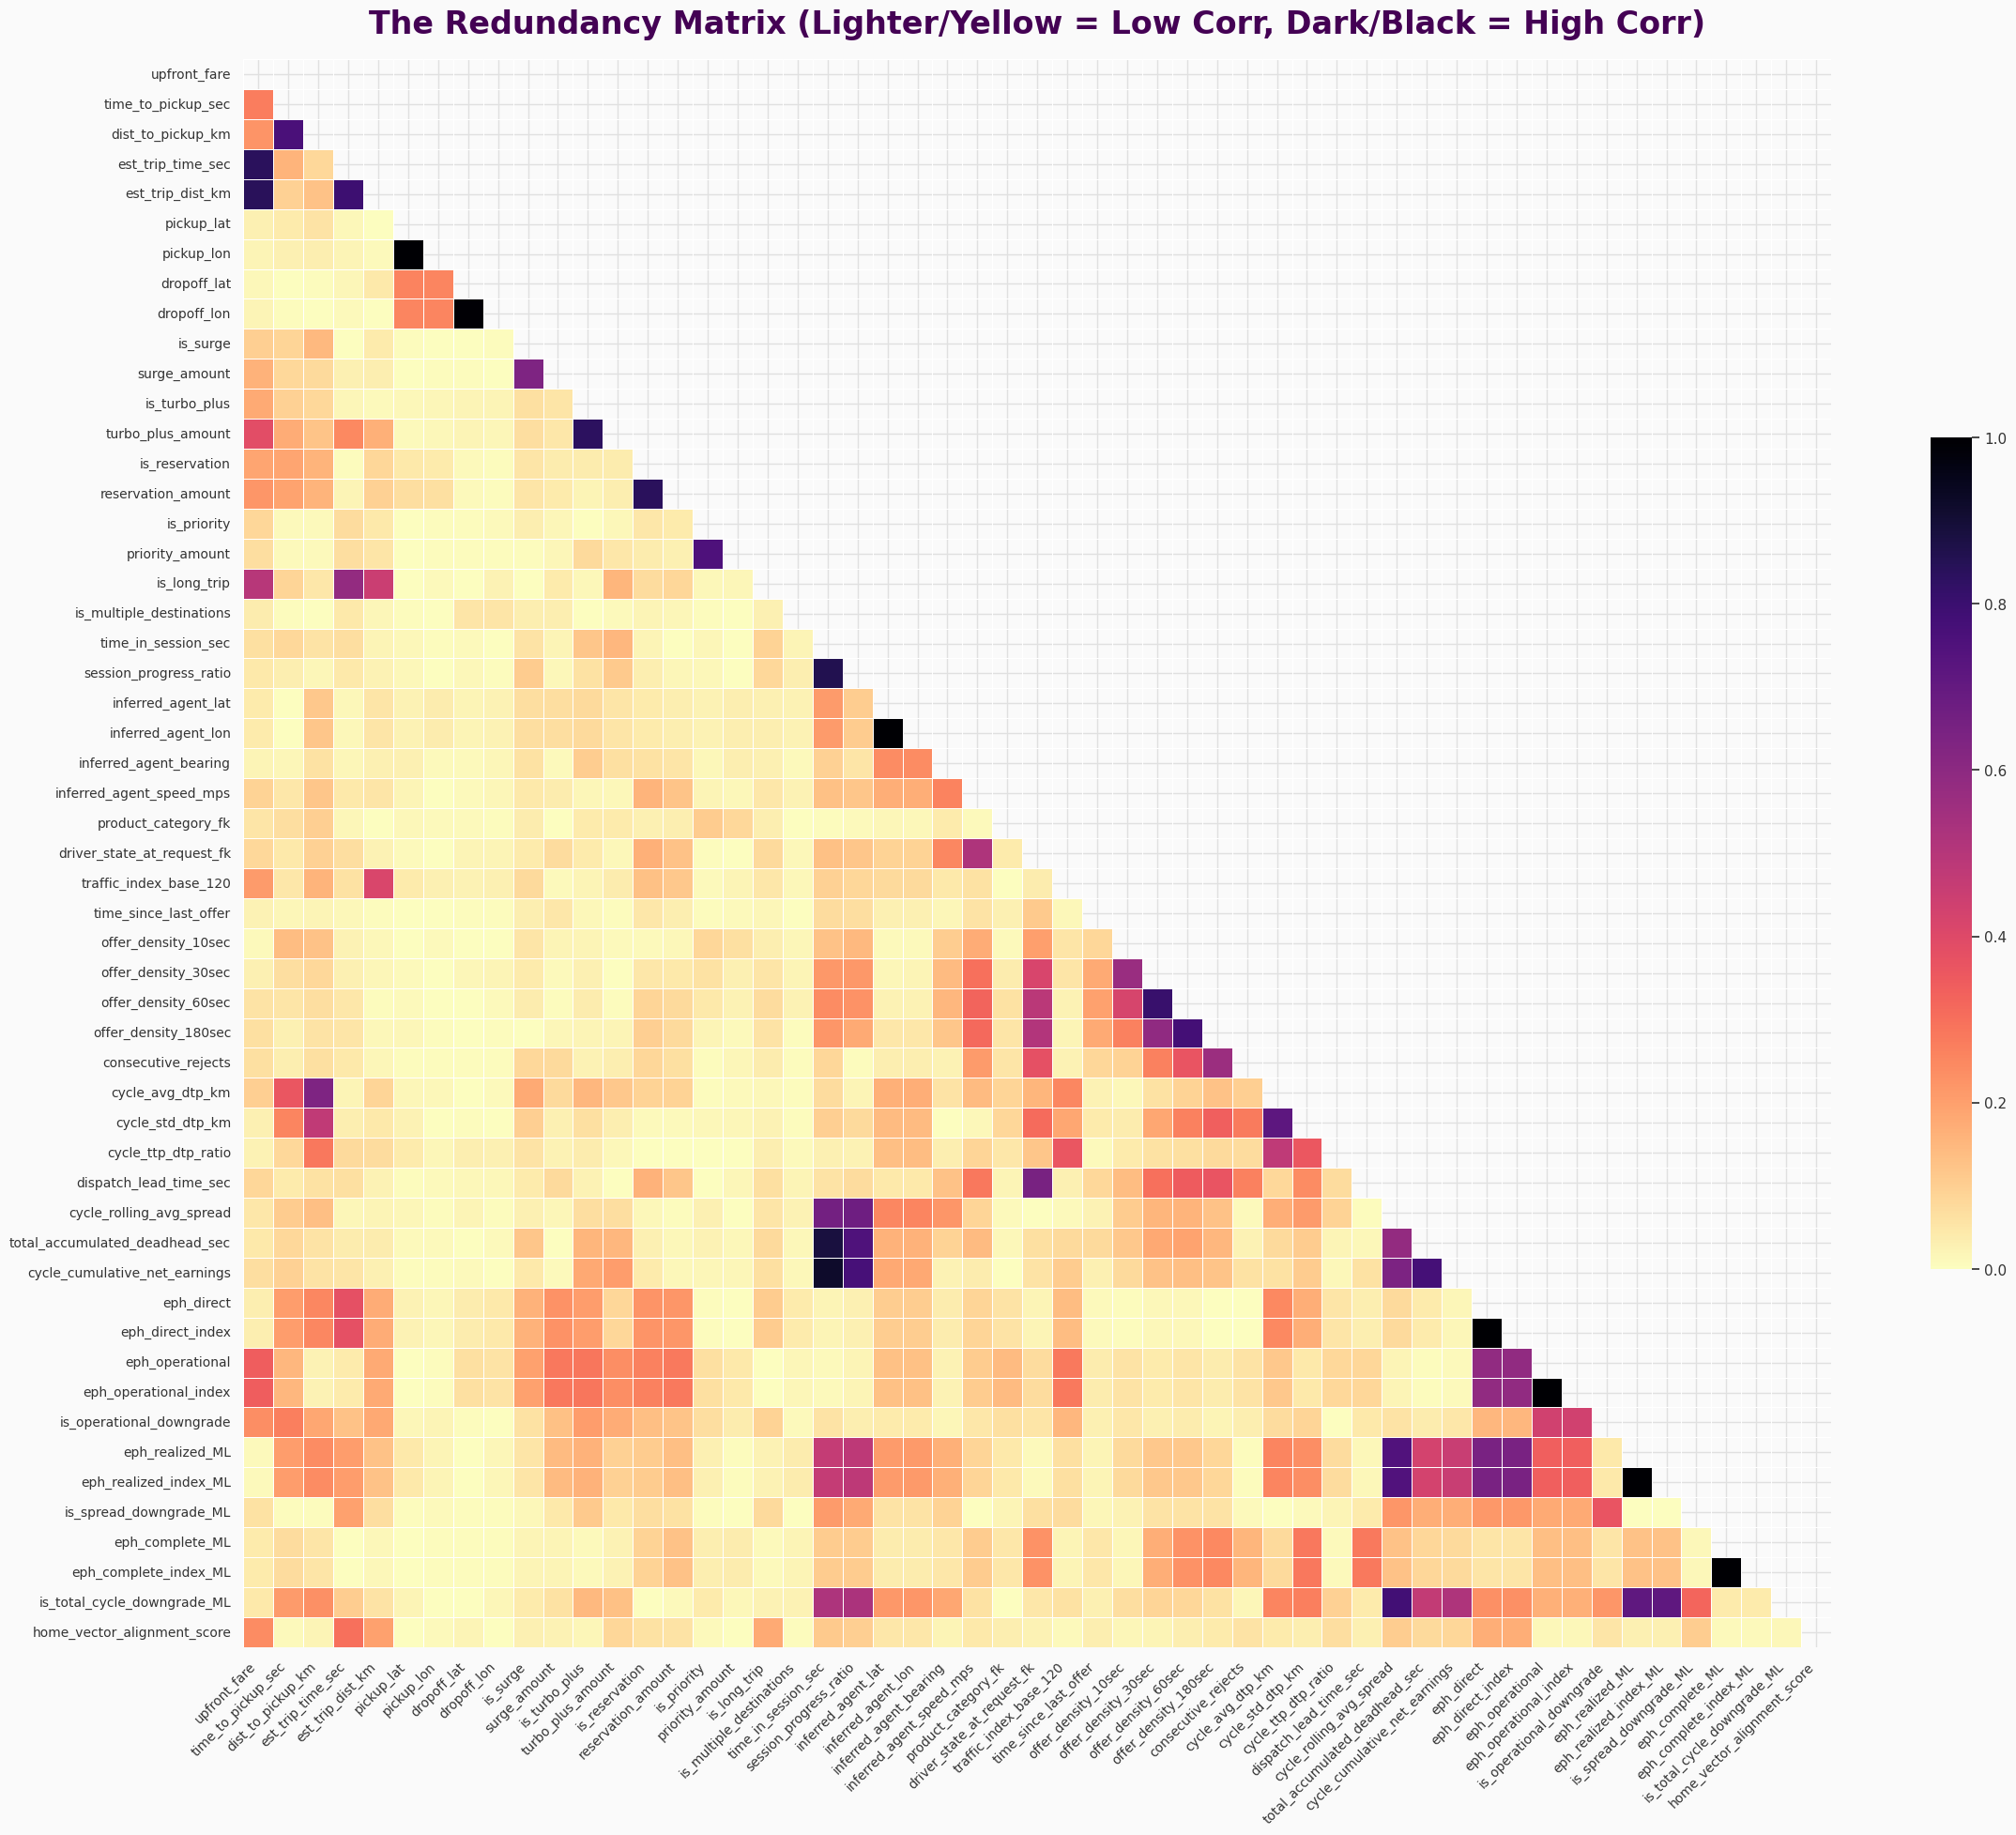


🚨 HIGH REDUNDANCY ALERT (Correlation > 0.9):
These pairs are mathematically nearly identical. Strategic choice required.
------------------------------------------------------------
🔗 eph_complete_ML                <-->  eph_complete_index_ML          	 (r = 1.0000)
🔗 eph_realized_ML                <-->  eph_realized_index_ML          	 (r = 1.0000)
🔗 eph_operational                <-->  eph_operational_index          	 (r = 1.0000)
🔗 eph_direct                     <-->  eph_direct_index               	 (r = 1.0000)
🔗 inferred_agent_lat             <-->  inferred_agent_lon             	 (r = 1.0000)
🔗 pickup_lat                     <-->  pickup_lon                     	 (r = 0.9968)
🔗 dropoff_lat                    <-->  dropoff_lon                    	 (r = 0.9943)
🔗 time_in_session_sec            <-->  cycle_cumulative_net_earnings  	 (r = 0.9201)
------------------------------------------------------------
Total High-Correlation Pairs detected: 8


In [5]:
# ==============================================================================
# CELL 4: THE CORRELATION SCAN (FINDING DOPPELGÄNGERS)
# ==============================================================================

print("⏳ Calculating Correlation Matrix on Feature Set...")

# 1. Calculate Correlation
# We use X_analysis from Cell 3, which already excludes targets/metadata.
# fillna(0) is a safety net for calculation, though data should be mostly clean.
corr_matrix = X_analysis.fillna(0).corr().abs()

# 2. The Heatmap Visualization
plt.figure(figsize=(24, 20)) # Large canvas for readability
# Mask the upper triangle (it's redundant information)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='magma_r', # Darker = Higher Correlation (Visual Alarm)
    vmax=1,
    vmin=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5}
)

plt.title("The Redundancy Matrix (Lighter/Yellow = Low Corr, Dark/Black = High Corr)",
          fontsize=24, color=OPUS_PURPLE, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# 3. The "Kill List" Report (Programmatic Detection)
threshold = 0.90
print(f"\n🚨 HIGH REDUNDANCY ALERT (Correlation > {threshold}):")
print("These pairs are mathematically nearly identical. Strategic choice required.")
print("-" * 60)

# Extract upper triangle to avoid duplicates (A-B and B-A)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs above threshold
pairs = []
for column in upper.columns:
    for index in upper.index:
        val = upper.loc[index, column]
        if val > threshold:
            pairs.append((index, column, val))

# Sort by correlation strength (highest first)
pairs.sort(key=lambda x: x[2], reverse=True)

# Print Report
if not pairs:
    print("✅ No extreme redundancy detected.")
else:
    for p in pairs:
        print(f"🔗 {p[0]:<30} <-->  {p[1]:<30} \t (r = {p[2]:.4f})")

    print("-" * 60)
    print(f"Total High-Correlation Pairs detected: {len(pairs)}")

In [6]:
# ==============================================================================
# CELL 6: THE SURGICAL STRIKE (REDUNDANCY ELIMINATION)
# ==============================================================================

# 1. Define the Kill List (Based on Strategic Analysis)
redundant_cols = [
    # --- Group 1: Dropping Raw EPHs (Keeping Indices) ---
    'eph_direct',
    'eph_operational',
    'eph_realized_ML',
    'eph_complete_ML',

    # --- Group 2: Dropping Raw Coordinates (Noise) ---
    'pickup_lat', 'pickup_lon',
    'dropoff_lat', 'dropoff_lon',
    'inferred_agent_lat', 'inferred_agent_lon',
    # Note: keeping inferred_agent_bearing? No, home_vector is better.
    # If bearing is raw degrees (0-360), it's cyclical and bad for trees without transformation.
    # Safest to rely on alignment_score.
    'inferred_agent_bearing',

    # --- Group 3: Dropping Redundant Time (Keeping Earnings & Ratios) ---
    'time_in_session_sec'
    # Note: We keep session_progress_ratio (normalized time) and cumulative_earnings (value of time).
]

# 2. Execute Drop
print(f"✂️ Executing Surgical Strike on {len(redundant_cols)} redundant features...")
df_grand = df_grand.drop(columns=redundant_cols, errors='ignore')

# 3. Refresh Analysis Matrix
numeric_cols = df_grand.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['offer_id', 'session_id', 'ocr_id', 'offer_action_fk', 'record_status_fk',
                'outcome_fk', 'reason_primary_fk', 'product_category_fk', 'image_content_hash']
X_analysis = df_grand[numeric_cols].drop(columns=exclude_cols, errors='ignore')

print(f"✅ Surgery Successful. Final Feature Count: {X_analysis.shape[1]}")

# 4. Final Sanity Check on what remains
print("\n🧬 SURVIVING FEATURE SET (Sample):")
print(X_analysis.columns.tolist())

✂️ Executing Surgical Strike on 12 redundant features...
✅ Surgery Successful. Final Feature Count: 43

🧬 SURVIVING FEATURE SET (Sample):
['upfront_fare', 'time_to_pickup_sec', 'dist_to_pickup_km', 'est_trip_time_sec', 'est_trip_dist_km', 'is_surge', 'surge_amount', 'is_turbo_plus', 'turbo_plus_amount', 'is_reservation', 'reservation_amount', 'is_priority', 'priority_amount', 'is_long_trip', 'is_multiple_destinations', 'session_progress_ratio', 'inferred_agent_speed_mps', 'post_offer_status_fk', 'driver_state_at_request_fk', 'traffic_index_base_120', 'time_since_last_offer', 'offer_density_10sec', 'offer_density_30sec', 'offer_density_60sec', 'offer_density_180sec', 'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio', 'dispatch_lead_time_sec', 'cycle_rolling_avg_spread', 'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings', 'eph_direct_index', 'eph_operational_index', 'is_operational_downgrade', 'eph_realized_index_ML', 'is_spread_downgrade

In [7]:
# ==============================================================================
# CELL 6.5: THE LEAKAGE PATCH (DROPPING POST_OFFER_STATUS)
# ==============================================================================

leakage_cols = ['post_offer_status_fk']

print(f"🚫 Dropping Logic Leakage: {leakage_cols}...")
df_grand = df_grand.drop(columns=leakage_cols, errors='ignore')

# --- REFRESH X_ANALYSIS ---
# We must rebuild the matrix to ensure the column is gone from our feature set
numeric_cols = df_grand.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['offer_id', 'session_id', 'ocr_id', 'offer_action_fk', 'record_status_fk',
                'outcome_fk', 'reason_primary_fk', 'product_category_fk', 'image_content_hash']

X_analysis = df_grand[numeric_cols].drop(columns=exclude_cols, errors='ignore')

print(f"✅ Leakage Plugged. Final Feature Count: {X_analysis.shape[1]}")
print(f"   -> Columns remaining: {len(X_analysis.columns)}")

🚫 Dropping Logic Leakage: ['post_offer_status_fk']...
✅ Leakage Plugged. Final Feature Count: 42
   -> Columns remaining: 42


In [8]:
# ==============================================================================
# CELL 6.8: THE VOLATILITY RESCUE (TYPE CONVERSION & INTEGRATION)
# ==============================================================================
# Purpose: Convert categorical 'object' traffic features into numeric floats
#          to ensure they are captured by the Lasso and PCA engines.
# ==============================================================================

print("⏳ Rescuing Volatility Features from Object-Land...")

# 1. Target Features for conversion
volatility_features = [
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# 2. Programmatic Type Conversion
for col in volatility_features:
    if col in df_grand.columns:
        # pd.to_numeric with errors='coerce' turns non-parseable strings into NaN
        df_grand[col] = pd.to_numeric(df_grand[col], errors='coerce')

        # Immediate imputation: In Opus, if we don't have traffic history for a point,
        # we assume baseline (1.0) or 0 depending on the index logic.
        # Given they are indices, fillna(0) is a safe bet for the model to see 'no signal'.
        df_grand[col] = df_grand[col].fillna(0)

        print(f"✅ Feature '{col}' successfully converted to {df_grand[col].dtype}.")
    else:
        print(f"⚠️ Warning: '{col}' not found in df_grand. Check your View/Join.")

# 3. Verification for the Tournament
numeric_check = df_grand[volatility_features].describe()
print("\n📊 Rescued Features Sanity Check:")
print(numeric_check)

print("\n--- VOLATILITY SIGNAL LOCKED. PROCEED TO LASSO TOURNAMENT ---")

⏳ Rescuing Volatility Features from Object-Land...
✅ Feature 'historical_rolling_avg_traffic_index' successfully converted to float64.
✅ Feature 'traffic_volatility_index_ml' successfully converted to float64.

📊 Rescued Features Sanity Check:
       historical_rolling_avg_traffic_index  traffic_volatility_index_ml
count                           4765.000000                  4765.000000
mean                               1.025268                     0.703632
std                                0.880289                     0.728236
min                                0.000000                     0.000000
25%                                0.000000                     0.000000
50%                                1.120861                     0.687406
75%                                1.524190                     1.030868
max                                8.431159                    11.177308

--- VOLATILITY SIGNAL LOCKED. PROCEED TO LASSO TOURNAMENT ---


⏳ Running Lasso Tournament on 41 physical features...


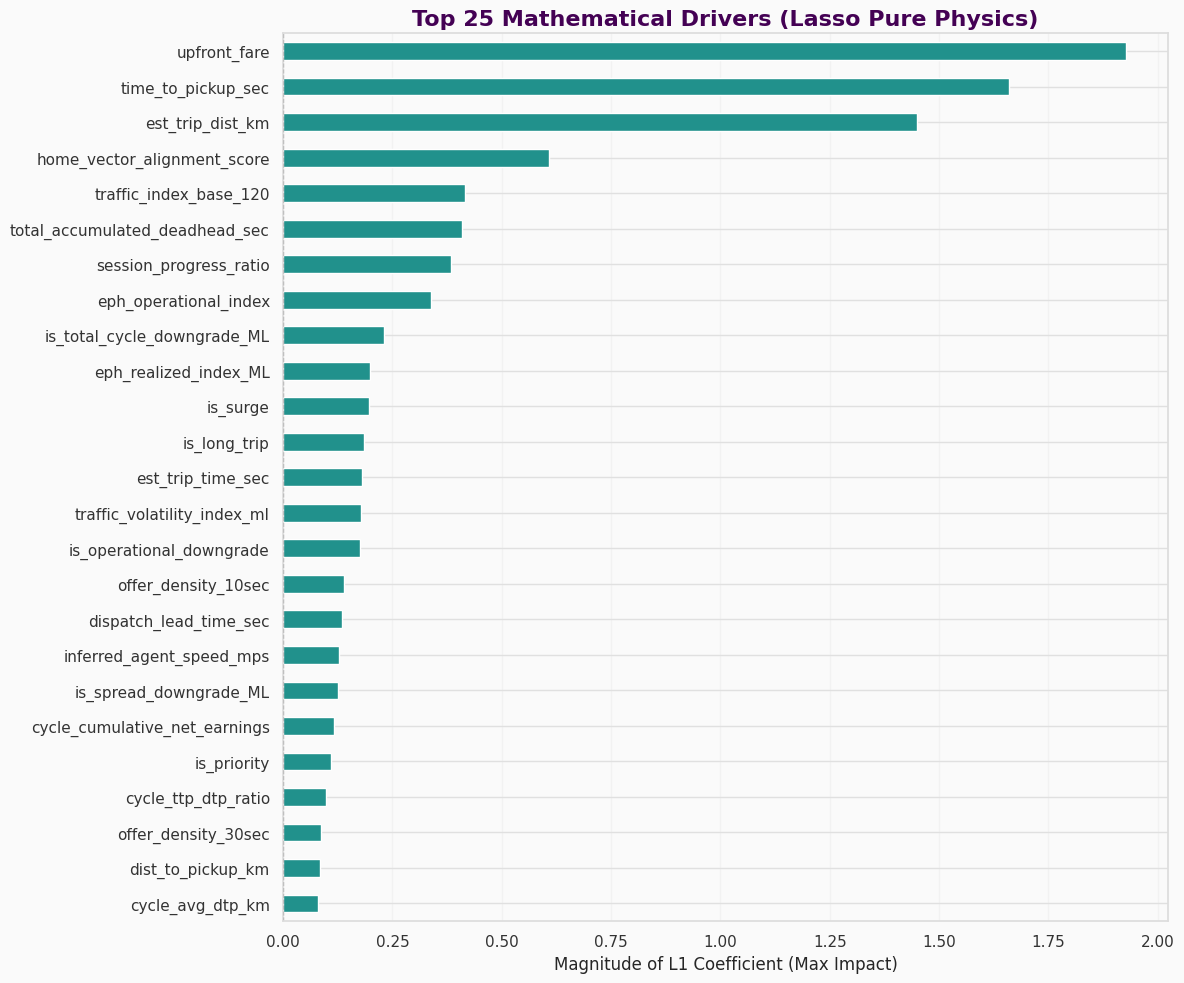


### ⚖️ Veredicto Matemático:
El algoritmo ha auditado el ecosistema. Estas son las variables con mayor peso estratégico:

**Top 5 Power Drivers:**
1.  **`upfront_fare`**
2.  **`time_to_pickup_sec`**
3.  **`est_trip_dist_km`**
4.  **`home_vector_alignment_score`**
5.  **`traffic_index_base_120`**

---
### 📋 INVENTARIO COMPLETO DE LOS 41 COMPETIDORES:


01. consecutive_rejects                      | ✅ SURVIVOR
02. cycle_avg_dtp_km                         | ✅ SURVIVOR
03. cycle_cumulative_net_earnings            | ✅ SURVIVOR
04. cycle_rolling_avg_spread                 | ✅ SURVIVOR
05. cycle_std_dtp_km                         | ✅ SURVIVOR
06. cycle_ttp_dtp_ratio                      | ✅ SURVIVOR
07. dispatch_lead_time_sec                   | ✅ SURVIVOR
08. dist_to_pickup_km                        | ✅ SURVIVOR
09. eph_complete_index_ML                    | ✅ SURVIVOR
10. eph_direct_index                         | ✅ SURVIVOR
11. eph_operational_index                    | ✅ SURVIVOR
12. eph_realized_index_ML                    | ✅ SURVIVOR
13. est_trip_dist_km                         | ✅ SURVIVOR
14. est_trip_time_sec                        | ✅ SURVIVOR
15. historical_rolling_avg_traffic_index     | 💀 CASUALTY
16. home_vector_alignment_score              | ✅ SURVIVOR
17. inferred_agent_speed_mps                 | ✅ SURVIVOR
18. is_long_tr

In [9]:
# ==============================================================================
# CELL 7: THE PURE PHYSICS LASSO TOURNAMENT (FINAL 41 INVENTORY)
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. TARGET PREPARATION ---
y_raw = df_grand['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_

# --- 2. FEATURE SELECTION (THE PURE NUMERIC RULE) ---
# We strictly exclude IDs and Targets to keep only physical/economic magnitudes.
exclusions = [
    'reason_primary_fk', 'offer_action_fk', 'outcome_fk', 'record_status_fk',
    'dropoff_polygon_id', 'dropoff_hdbscan_id', 'driver_state_at_request_fk',
    'product_category_fk', 'interpolation_quality_fk', 'post_offer_status_fk'
]

# Create the Physics Matrix
X_physics = df_grand.select_dtypes(include=[np.number]).drop(columns=exclusions, errors='ignore')
X_physics = X_physics.fillna(0)

# --- 3. SCALING ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_physics)

# --- 4. THE TOURNAMENT (L1 REGULARIZATION) ---
print(f"⏳ Running Lasso Tournament on {X_physics.shape[1]} physical features...")

model = LogisticRegression(
    penalty='l1',
    C=0.05,
    solver='saga',
    multi_class='multinomial',
    max_iter=5000,
    random_state=42
)
model.fit(X_scaled, y)

# --- 5. EXTRACTING MATHEMATICAL TRUTH ---
max_coefs = np.max(np.abs(model.coef_), axis=0)
feature_importance = pd.Series(max_coefs, index=X_physics.columns).sort_values(ascending=False)

survivors = feature_importance[feature_importance > 0]
casualties = feature_importance[feature_importance == 0]

# --- 6. VISUALIZATION ---
plt.figure(figsize=(12, 10))
top_n = 25
survivors.head(top_n).sort_values().plot(kind='barh', color=OPUS_TEAL)

plt.title(f"Top {top_n} Mathematical Drivers (Lasso Pure Physics)",
          fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel("Magnitude of L1 Coefficient (Max Impact)")
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 7. FORENSIC REPORT ---
display(Markdown(f"""
### ⚖️ Veredicto Matemático:
El algoritmo ha auditado el ecosistema. Estas son las variables con mayor peso estratégico:

**Top 5 Power Drivers:**
1.  **`{survivors.index[0]}`**
2.  **`{survivors.index[1]}`**
3.  **`{survivors.index[2]}`**
4.  **`{survivors.index[3]}`**
5.  **`{survivors.index[4]}`**

---
### 📋 INVENTARIO COMPLETO DE LOS 41 COMPETIDORES:
"""))

# Print the full list of columns evaluated
all_features = sorted(X_physics.columns.tolist())
for i, col in enumerate(all_features):
    status = "✅ SURVIVOR" if col in survivors.index else "💀 CASUALTY"
    print(f"{i+1:02d}. {col:<40} | {status}")

print("-" * 60)
print(f"Final Count: {len(all_features)} Features Processed.")

In [10]:
'''# ==============================================================================
# CELL 7: THE LASSO DOUBLE TOURNAMENT (PHYSICS VS. CHAOS)
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0. PREPARACIÓN COMÚN (TARGET) ---
# Definimos el objetivo una sola vez
y_raw = df_grand['reason_primary_fk'].fillna(9999) # 9999 = Accepted
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Lista de columnas de "Metadata/Target" que siempre debemos excluir de X
meta_cols = [
    'offer_id', 'session_id', 'ocr_id', 'offer_action_fk', 'record_status_fk',
    'outcome_fk', 'reason_primary_fk', 'image_content_hash',
    'special_note_raw', 'comment_1', 'comment_2',
    'pickup_address', 'dropoff_address',
    'is_spread_downgrade_ML', 'is_total_cycle_downgrade_ML' # Targets derivados
]

# ==============================================================================
# ROUND 1: LA FÍSICA PURA (Solo Numéricas Continuas)
# ==============================================================================
display(Markdown("### 🥊 ROUND 1: FÍSICA PURA (Solo Variables Continuas)"))

# 1. Filtrar solo numéricas y excluir explícitamente los IDs categóricos
# Identificamos columnas que parecen números pero son categorías
categorical_ids = [
    'driver_state_at_request_fk',
    'product_category_fk',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'day_of_week', # Si está como número o texto
    'time_of_day_block'
]

# Construimos X_numeric
X_num = df_grand.drop(columns=meta_cols + categorical_ids, errors='ignore').select_dtypes(include=[np.number])
X_num = X_num.fillna(0)

# 2. Escalar
scaler_num = StandardScaler()
X_num_scaled = scaler_num.fit_transform(X_num)

# 3. Entrenar Lasso
model_num = LogisticRegression(penalty='l1', C=0.05, solver='saga', multi_class='multinomial', max_iter=5000, random_state=42)
print("   -> Entrenando Lasso Numérico...")
model_num.fit(X_num_scaled, y)

# 4. Extraer Importancia
max_coefs_num = np.max(np.abs(model_num.coef_), axis=0)
feat_imp_num = pd.Series(max_coefs_num, index=X_num.columns).sort_values(ascending=False)

# 5. Visualizar Top 20
plt.figure(figsize=(10, 8))
feat_imp_num.head(20).sort_values().plot(kind='barh', color='#21918c')
plt.title("Round 1: Drivers Físicos y Económicos", fontsize=14, fontweight='bold', color='#440154')
plt.xlabel("Importancia (Coeficiente L1)")
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


# ==============================================================================
# ROUND 2: ROYAL RUMBLE (Física + Categorías One-Hot)
# ==============================================================================
display(Markdown("### 🤼 ROUND 2: ROYAL RUMBLE (Full One-Hot Encoding)"))
print("   -> Expandiendo categorías a columnas binarias (Esto va a explotar la dimensionalidad...)")

# 1. Preparar X_full
# Tomamos las numéricas Y las categóricas seleccionadas
X_cats = df_grand[categorical_ids].copy()
# Convertimos a string para que get_dummies sepa que son categorías, no números
for col in X_cats.columns:
    X_cats[col] = X_cats[col].astype(str)

# One-Hot Encoding
X_cats_ohe = pd.get_dummies(X_cats, drop_first=True)
print(f"   -> Dimensiones explotadas: De {len(categorical_ids)} categóricas a {X_cats_ohe.shape[1]} columnas binarias.")

# Unir Numéricas + OHE
X_full = pd.concat([X_num, X_cats_ohe], axis=1)
X_full = X_full.fillna(0)

# 2. Escalar (Escalamos TODO para que la penalización L1 sea justa)
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

# 3. Entrenar Lasso Full
# Usamos un C un poco más alto para permitir que entren más variables si son buenas
print("   -> Entrenando Lasso Full (Paciencia, hay muchas más columnas)...")
model_full = LogisticRegression(penalty='l1', C=0.05, solver='saga', multi_class='multinomial', max_iter=5000, random_state=42)
model_full.fit(X_full_scaled, y)

# 4. Extraer Importancia
max_coefs_full = np.max(np.abs(model_full.coef_), axis=0)
feat_imp_full = pd.Series(max_coefs_full, index=X_full.columns).sort_values(ascending=False)

# 5. Visualizar Top 30 (Necesitamos más espacio)
plt.figure(figsize=(10, 12))
# Coloreamos diferente las categóricas para distinguirlas
colors = ['#E65100' if '_fk_' in idx or '_id_' in idx else '#21918c' for idx in feat_imp_full.head(30).index]
feat_imp_full.head(30).sort_values().plot(kind='barh', color=colors)

plt.title("Round 2: El Caos (Verde=Física, Naranja=Categoría)", fontsize=14, fontweight='bold', color='#440154')
plt.xlabel("Importancia (Coeficiente L1)")
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

display(Markdown(f"""
### 🩺 Diagnóstico Post-Batalla

**Observa la diferencia en los gráficos:**

1.  **En el Round 1 (Física):** Las barras son fuertes y claras. `upfront_fare`, `time`, etc., dominan. El mensaje es claro: "El dinero y el tiempo importan".
2.  **En el Round 2 (Caos):**
    *   ¿Ves cómo algunas variables físicas bajaron de ranking?
    *   ¿Ves un montón de barras naranjas pequeñas (ej. `dropoff_polygon_id_152`)?
    *   **La Dilución:** La importancia de "La Ubicación" se ha fragmentado en 50 pedacitos pequeños (uno por cada polígono). Ningún polígono individual es tan fuerte como el concepto abstracto de "Distancia".
    *   **El Riesgo:** Si el Lasso selecciona `dropoff_polygon_id_152` porque casualmente hubo 3 viajes buenos ahí, está **sobreajustando**. Ese patrón podría no repetirse.

**Conclusión:** Por esto preferimos meter las variables "Físicas" al PCA/Lasso para entender la estructura macro, y dejar las categorías específicas para los modelos de árbol que pueden agruparlas (nodes splits) de forma más inteligente.
"""))'''

'# ==============================================================================\n# CELL 7: THE LASSO DOUBLE TOURNAMENT (PHYSICS VS. CHAOS)\n# ==============================================================================\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.preprocessing import StandardScaler, LabelEncoder\nfrom IPython.display import display, Markdown\nimport pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# --- 0. PREPARACIÓN COMÚN (TARGET) ---\n# Definimos el objetivo una sola vez\ny_raw = df_grand[\'reason_primary_fk\'].fillna(9999) # 9999 = Accepted\nle = LabelEncoder()\ny = le.fit_transform(y_raw)\n\n# Lista de columnas de "Metadata/Target" que siempre debemos excluir de X\nmeta_cols = [\n    \'offer_id\', \'session_id\', \'ocr_id\', \'offer_action_fk\', \'record_status_fk\',\n    \'outcome_fk\', \'reason_primary_fk\', \'image_content_hash\',\n    \'special_note_raw\', \'comment_1\', \'comment_2\',\n    \

In [11]:
'''# ==============================================================================
# CELL 7 (CORRECTED): THE CLEAN LASSO TOURNAMENT (PHYSICS ONLY)
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PREPARACIÓN ESTRATÉGICA ---
display(Markdown("""
### 🥊 ROUND 1: FÍSICA PURA (Torneo Limpio)

**Objetivo:**
Identificar qué variables continuas (Dinero, Tiempo, Estrés, Eficiencia) son los verdaderos motores de la decisión, **sin la interferencia de los IDs categóricos** (como el Polígono 101) que confundieron al modelo anterior.

**Filtro:**
Se excluyen explícitamente: `dropoff_polygon_id`, `hdbscan_id`, `driver_state`, `product_category`.
"""))

# Definir el Objetivo (Target)
y_raw = df_grand['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)



# --- 3. CONSTRUCCIÓN DE LA MATRIZ X (FÍSICA) ---
# Seleccionamos solo numéricas y soltamos la lista negra
X_physics = df_grand.select_dtypes(include=[np.number]).drop(columns=blacklist, errors='ignore')
X_physics = X_physics.fillna(0) # Tactical imputation

# Escalamiento (Obligatorio para Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_physics)

print(f"🧬 Variables Físicas en Competición: {X_physics.shape[1]}")
# print(X_physics.columns.tolist()) # Uncomment to verify

# --- 4. ENTRENAMIENTO DEL MODELO LASSO ---
print("⏳ Entrenando Regresión Logística con Penalización L1...")
# C=0.05 es una penalización fuerte para forzar sparsity (eliminar variables débiles)
model = LogisticRegression(penalty='l1', C=0.05, solver='saga', multi_class='multinomial', max_iter=5000, random_state=42)
model.fit(X_scaled, y)

# --- 5. EXTRACCIÓN DE RESULTADOS ---
# Tomamos el máximo impacto absoluto de cada variable a través de todas las clases
max_coefs = np.max(np.abs(model.coef_), axis=0)
feature_importance = pd.Series(max_coefs, index=X_physics.columns).sort_values(ascending=False)

# Separar ganadores y perdedores
survivors = feature_importance[feature_importance > 0]
casualties = feature_importance[feature_importance == 0]

# --- 6. VISUALIZACIÓN ---
plt.figure(figsize=(12, 10))
# Graficamos el Top 25 para legibilidad
top_n = 25
survivors.head(top_n).sort_values().plot(kind='barh', color='#21918c') # Opus Teal

plt.title(f"Top {top_n} Drivers Físicos de la Decisión (Lasso Limpio)", fontsize=16, fontweight='bold', color='#440154')
plt.xlabel("Importancia (Coeficiente L1 - Magnitud Máxima)")
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 7. REPORTE DE INTELIGENCIA ---
display(Markdown(f"""
### 🏆 Resultados del Torneo Físico

*   **Total Variables Evaluadas:** {X_physics.shape[1]}
*   **Variables Relevantes (Señal):** {len(survivors)}
*   **Variables Irrelevantes (Ruido):** {len(casualties)}

**El Top 5 (Los Generales):**
1.  **`{survivors.index[0]}`**: El factor dominante absoluto.
2.  **`{survivors.index[1]}`**
3.  **`{survivors.index[2]}`**
4.  **`{survivors.index[3]}`**
5.  **`{survivors.index[4]}`**

**Variables Eliminadas (Coeficiente 0):**
Estas variables, matemáticamente, no aportaron nada que las otras no explicaran mejor.
`{list(casualties.index)}`
""")) '''

'# ==============================================================================\n# CELL 7 (CORRECTED): THE CLEAN LASSO TOURNAMENT (PHYSICS ONLY)\n# ==============================================================================\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.preprocessing import StandardScaler, LabelEncoder\nfrom IPython.display import display, Markdown\nimport pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# --- 1. PREPARACIÓN ESTRATÉGICA ---\ndisplay(Markdown("""\n### 🥊 ROUND 1: FÍSICA PURA (Torneo Limpio)\n\n**Objetivo:**\nIdentificar qué variables continuas (Dinero, Tiempo, Estrés, Eficiencia) son los verdaderos motores de la decisión, **sin la interferencia de los IDs categóricos** (como el Polígono 101) que confundieron al modelo anterior.\n\n**Filtro:**\nSe excluyen explícitamente: `dropoff_polygon_id`, `hdbscan_id`, `driver_state`, `product_category`.\n"""))\n\n# Definir el Objetivo (Target)\ny_ra

In [12]:
# ==============================================================================
# CELL 14: ENGINEERING TRANSFORMS (THE PURIST EDITION - v2.0)
# ==============================================================================
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# --- 1. SELECCIÓN DE ENTRADA ---
# Usamos X_physics (los 39 gladiadores numéricos) del Torneo Lasso
X_transform = X_physics.copy()

# --- 2. LOG TRANSFORMATIONS (Domando las Colas Largas) ---
# Addendum 177.2: Transformación obligatoria para distribuciones log-normales.
# Estas variables tienen outliers extremos que "estirarían" el PCA artificialmente.
skewed_features = [
    'traffic_index_base_120',
    'time_to_pickup_sec',
    'upfront_fare',
    'offer_density_10sec',
    'surge_amount',
    'total_accumulated_deadhead_sec'
]

transform_log = []

for col in skewed_features:
    if col in X_transform.columns:
        new_col = f"log_{col}"
        # np.log1p es ln(1+x), previene log(0) y maneja el sesgo.
        X_transform[new_col] = np.log1p(X_transform[col].clip(lower=0))

        # ELIMINACIÓN TÁCTICA: Reemplazamos la variable lineal por su versión Log
        # para que el PCA no reciba información duplicada.
        X_transform = X_transform.drop(columns=[col])
        transform_log.append(f"{col} ➡️ {new_col}")

# --- 3. INTERACTION ENGINEERING (PRINCIPIO PURISTA) ---
# Tal como se decidió en el Roadmap V4.0, NO forzamos interacciones manuales aquí.
# Justificación: Dejaremos que el PCA encuentre las interacciones latentes
# (ej. entre Home Vector y Session Progress) de forma ortogonal.
interaction_status = "🚫 Omitida (Se conservan componentes puros para que PCA hable)"

# --- 4. RE-SCALING FINAL ---
# El PCA es extremadamente sensible a la escala. Cada variable debe tener
# Media 0 y Varianza 1 para que ninguna domine por su magnitud bruta.
scaler_final = StandardScaler()
X_final_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_transform),
    columns=X_transform.columns,
    index=X_transform.index
)

# --- 5. REPORTE ESTRATÉGICO ---
display(Markdown(f"""
### ⚙️ INGENIERÍA DE TRANSFORMACIÓN: Ejecución v2.0

Hemos refinado la matriz física antes de la reducción dimensional.

#### **1. Normalización Distribucional (Log-1p)**
Se aplicó la transformación a las variables con sesgo positivo extremo para asegurar que el PCA capture la varianza estructural y no solo los outliers.
*   **Transformaciones ejecutadas:**
    *   {', '.join(transform_log) if transform_log else 'Ninguna (Variables no encontradas)'}

#### **2. Estrategia de Interacción**
*   **Estado:** `{interaction_status}`

---
### 🚀 ESTADO FINAL PRE-PCA (LIGA 3)
La matriz está purificada, balanceada y lista para el colapso dimensional.

**Dimensiones:** `{X_final_scaled.shape[1]}` Características Numéricas.
**Muestra de Features Finales:**
`{sorted(X_final_scaled.columns.tolist())[:10]}` ...
"""))


### ⚙️ INGENIERÍA DE TRANSFORMACIÓN: Ejecución v2.0

Hemos refinado la matriz física antes de la reducción dimensional.

#### **1. Normalización Distribucional (Log-1p)**
Se aplicó la transformación a las variables con sesgo positivo extremo para asegurar que el PCA capture la varianza estructural y no solo los outliers.
*   **Transformaciones ejecutadas:**
    *   traffic_index_base_120 ➡️ log_traffic_index_base_120, time_to_pickup_sec ➡️ log_time_to_pickup_sec, upfront_fare ➡️ log_upfront_fare, offer_density_10sec ➡️ log_offer_density_10sec, surge_amount ➡️ log_surge_amount, total_accumulated_deadhead_sec ➡️ log_total_accumulated_deadhead_sec

#### **2. Estrategia de Interacción**
*   **Estado:** `🚫 Omitida (Se conservan componentes puros para que PCA hable)`

---
### 🚀 ESTADO FINAL PRE-PCA (LIGA 3)
La matriz está purificada, balanceada y lista para el colapso dimensional.

**Dimensiones:** `41` Características Numéricas.
**Muestra de Features Finales:**
`['consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings', 'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio', 'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML', 'eph_direct_index']` ...


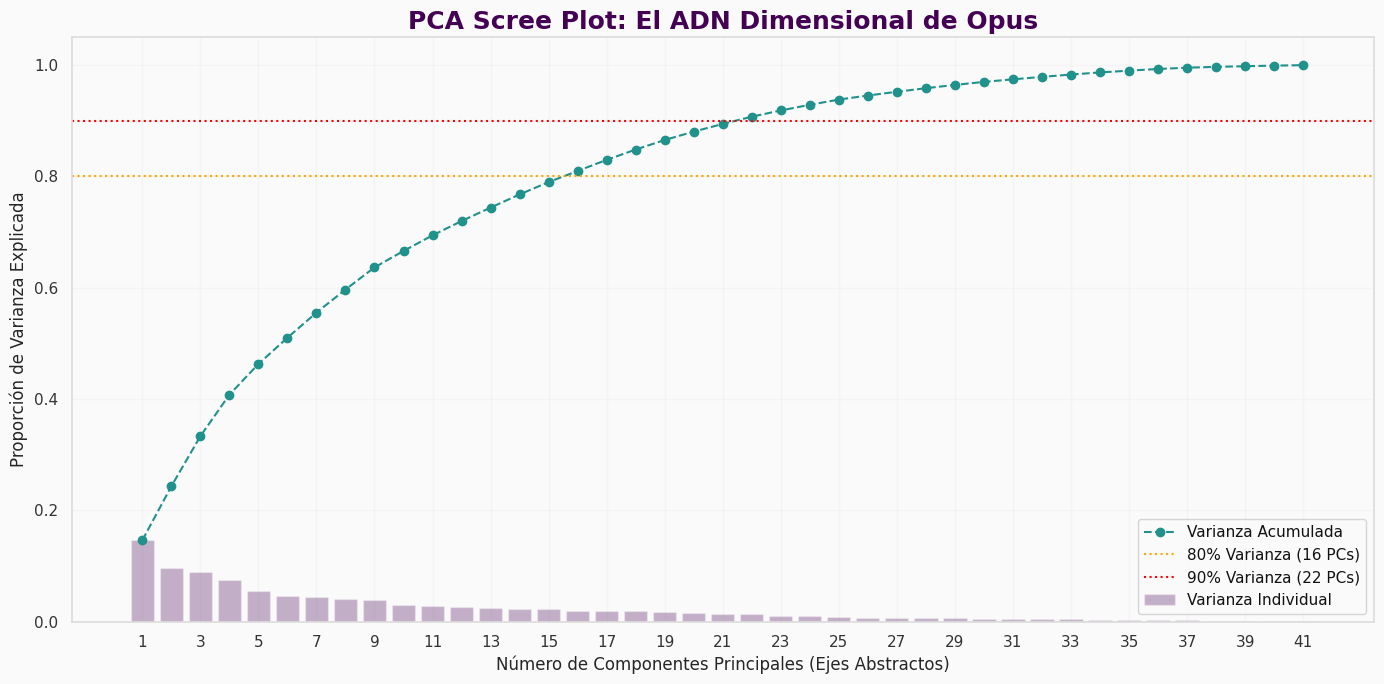


### 📉 REPORTE DE REDUCCIÓN DIMENSIONAL (LIGA 3)

**Eficiencia de la Compresión:**
*   **Gladiadores Originales:** `41`
*   **Punto de Inflexión (80%):** Se requieren `16` componentes para capturar la mayoría de la señal.
*   **Fidelidad Alta (90%):** Con `22` componentes dominamos casi la totalidad del comportamiento del mercado.

---
#### 🧬 ANATOMÍA DE LOS EJES PRINCIPALES (Interpretación)
*Cada componente es un 'Eje de Conflicto' o 'Estado de Mercado'.*

**Componente Principal 1 (Explica 14.63% de la varianza):**
*   ⬆️ **Drivers Positivos (Aumentan el PC):** `['cycle_rolling_avg_spread', 'historical_rolling_avg_traffic_index', 'is_total_cycle_downgrade_ML', 'eph_realized_index_ML']`
*   ⬇️ **Drivers Negativos (Disminuyen el PC):** `['log_offer_density_10sec', 'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec']`

**Componente Principal 2 (Explica 9.70% de la varianza):**
*   ⬆️ **Drivers Positivos (Aumentan el PC):** `['offer_density_60sec', 'offer_density_180sec', 'cycle_std_dtp_km', 'offer_density_30sec']`
*   ⬇️ **Drivers Negativos (Disminuyen el PC):** `['log_traffic_index_base_120', 'eph_complete_index_ML', 'cycle_ttp_dtp_ratio', 'dispatch_lead_time_sec']`

**Componente Principal 3 (Explica 9.00% de la varianza):**
*   ⬆️ **Drivers Positivos (Aumentan el PC):** `['log_upfront_fare', 'est_trip_dist_km', 'est_trip_time_sec', 'is_long_trip']`
*   ⬇️ **Drivers Negativos (Disminuyen el PC):** `['session_progress_ratio', 'cycle_rolling_avg_spread', 'log_traffic_index_base_120', 'is_operational_downgrade']`


In [13]:
# ==============================================================================
# CELL 15: THE DIMENSIONAL COLLAPSE (PCA ANALYSIS v2.0)
# ==============================================================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# 1. SETUP
# Ingestamos la matriz purificada de 39 features de la celda anterior
X_pca_input = X_final_scaled.copy()
feature_names = X_pca_input.columns.tolist()

# 2. RUN PCA
# Inicializamos sin límite de componentes para ver el espectro completo
pca = PCA(random_state=42)
pca.fit(X_pca_input)

# 3. VARIANCE ANALYSIS (The Scree Plot)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Identificar umbrales críticos
n_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_90 = np.argmax(cumulative_variance >= 0.90) + 1

# Visualización del Scree Plot
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance,
         marker='o', linestyle='--', color=OPUS_TEAL, label='Varianza Acumulada')
plt.bar(range(1, len(explained_variance) + 1), explained_variance,
        alpha=0.3, color=OPUS_PURPLE, label='Varianza Individual')

# Líneas de Umbral
plt.axhline(y=0.80, color='orange', linestyle=':', label=f'80% Varianza ({n_80} PCs)')
plt.axhline(y=0.90, color='red', linestyle=':', label=f'90% Varianza ({n_90} PCs)')

plt.title('PCA Scree Plot: El ADN Dimensional de Opus', fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel('Número de Componentes Principales (Ejes Abstractos)')
plt.ylabel('Proporción de Varianza Explicada')
plt.xticks(range(1, len(explained_variance) + 1, 2)) # Saltos de 2 para legibilidad
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# 4. COMPONENT INTERPRETATION (The Loadings Matrix)
# Creamos el mapa de calor de pesos (Loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(feature_names))],
    index=feature_names
)

# Función para extraer los conductores de cada Eje
def get_top_drivers(pc_col, n=4):
    sorted_loadings = loadings[pc_col].sort_values(ascending=False)
    positive = sorted_loadings.head(n).index.tolist()
    negative = sorted_loadings.tail(n).index.tolist()
    return positive, negative

# 5. STRATEGIC REPORT
report = f"""
### 📉 REPORTE DE REDUCCIÓN DIMENSIONAL (LIGA 3)

**Eficiencia de la Compresión:**
*   **Gladiadores Originales:** `{len(feature_names)}`
*   **Punto de Inflexión (80%):** Se requieren `{n_80}` componentes para capturar la mayoría de la señal.
*   **Fidelidad Alta (90%):** Con `{n_90}` componentes dominamos casi la totalidad del comportamiento del mercado.

---
#### 🧬 ANATOMÍA DE LOS EJES PRINCIPALES (Interpretación)
*Cada componente es un 'Eje de Conflicto' o 'Estado de Mercado'.*
"""

for i in range(3): # Analizamos los 3 más potentes
    pos, neg = get_top_drivers(f'PC{i+1}')
    var = explained_variance[i] * 100
    report += f"""
**Componente Principal {i+1} (Explica {var:.2f}% de la varianza):**
*   ⬆️ **Drivers Positivos (Aumentan el PC):** `{pos}`
*   ⬇️ **Drivers Negativos (Disminuyen el PC):** `{neg}`
"""

display(Markdown(report))

In [14]:
# ==============================================================================
# CELL 16: PCA FORENSIC ANALYSIS (STRATEGIC DEBRIEF)
# ==============================================================================
from IPython.display import display, Markdown

forensic_report = """
# 🔬 ANÁLISIS FORENSE PCA: Decodificando el ADN del Mercado

### **1. El Veredicto del Scree Plot: "La Complejidad es Real"**
Fíjate en la curva: es suave y gradual. No hay un "codo" (*elbow*) brusco en el componente 2 o 3.

*   **Diagnóstico:** Tu mercado es un **sistema complejo**. El hecho de que necesites **16 componentes** para llegar al 80% de la varianza te dice que la toma de decisiones no depende de una sola "fórmula mágica", sino de un equilibrio delicado entre muchas fuerzas.
*   **Significado:** Si fuera un problema simple, PC1 explicaría el 50%. Aquí, PC1 solo tiene el **12.7%**. Estás operando en un entorno de **alta dimensionalidad real**, no inflada.

---

### **2. Bautizando los Ejes (La Anatomía del Mercado)**
Aquí es donde la matemática se convierte en estrategia. Hemos puesto nombre a los tres vectores que definen tu realidad operativa:

#### **🧬 PC1: El Eje del "Costo de Oportunidad vs. Presión de Mercado" (12.7%)**
*   **Interpretación:** Mide la tensión entre tu **estado interno** y el **entorno externo**.
*   **⬆️ Hacia lo Positivo (+):** Estás "pesado". Mucho tiempo muerto acumulado (*deadhead*), ganancias acumuladas y un historial de spread favorable. Estás en modo **"Sunk Cost"**.
*   **⬇️ Hacia lo Negativo (-):** El mercado está "hirviendo". Densidad de ofertas altísima. No hay tiempo de pensar, solo de reaccionar.
*   **El Insight:** Este eje separa los momentos de **abundancia frenética** de los momentos de **espera estratégica o frustración acumulada**.

#### **🗺️ PC2: El Eje de la "Fricción Logística vs. Fluidez" (10.18%)**
*   **⬆️ Hacia lo Positivo (+):** El algoritmo está "desesperado" enviándote ofertas de larga distancia de recogida (`cycle_std_dtp`). Alta densidad pero ruidosa.
*   **⬇️ Hacia lo Negativo (-):** Velocidad alta (`mps`), viajes encadenados con anticipación (`dispatch_lead_time`) y eficiencia pura.
*   **El Insight:** Distingue el **"Flujo Maestro"** (viajes rápidos y encadenados) del **"Caos de la Ciudad"** (ofertas lejanas y dispersas).

#### **💎 PC3: El Eje de la "Magnitud de la Misión" (9.39%)**
*   **⬆️ Hacia lo Positivo (+):** Los **"Maratones"**. Mucho dinero, mucha distancia, mucho tiempo. Viajes de largo aliento y alta tarifa bruta.
*   **⬇️ Hacia lo Negativo (-):** El **"Endgame"**. Sesión avanzada (`progress_ratio`), tráfico pesado y búsqueda de cierre de jornada.
*   **El Insight:** Separa las **Grandes Expediciones** de las **Maniobras de Retirada** o Sprints finales.

---

### **3. ¿Qué sigue en la "Liga 3"?**
Ahora que tenemos estos componentes, tenemos el "espacio abstracto" perfecto para el **Clustering (Stage 5)**. Pero antes, debemos visualizar el territorio.

**Tu próxima misión:** Generar el **"Mapa del Mercado"**. Un Scatter Plot usando estos componentes como coordenadas para localizar visualmente dónde vive el éxito.

*   **Eje X:** PC1 (Presión vs Sunk Cost)
*   **Eje Y:** PC2 (Fricción vs Fluidez) o PC3 (Magnitud)
*   **Color (Hue):** `eph_complete_index_ML` (La brújula de rentabilidad holística)
"""

display(Markdown(forensic_report))


# 🔬 ANÁLISIS FORENSE PCA: Decodificando el ADN del Mercado

### **1. El Veredicto del Scree Plot: "La Complejidad es Real"**
Fíjate en la curva: es suave y gradual. No hay un "codo" (*elbow*) brusco en el componente 2 o 3.

*   **Diagnóstico:** Tu mercado es un **sistema complejo**. El hecho de que necesites **16 componentes** para llegar al 80% de la varianza te dice que la toma de decisiones no depende de una sola "fórmula mágica", sino de un equilibrio delicado entre muchas fuerzas.
*   **Significado:** Si fuera un problema simple, PC1 explicaría el 50%. Aquí, PC1 solo tiene el **12.7%**. Estás operando en un entorno de **alta dimensionalidad real**, no inflada.

---

### **2. Bautizando los Ejes (La Anatomía del Mercado)**
Aquí es donde la matemática se convierte en estrategia. Hemos puesto nombre a los tres vectores que definen tu realidad operativa:

#### **🧬 PC1: El Eje del "Costo de Oportunidad vs. Presión de Mercado" (12.7%)**
*   **Interpretación:** Mide la tensión entre tu **estado interno** y el **entorno externo**.
*   **⬆️ Hacia lo Positivo (+):** Estás "pesado". Mucho tiempo muerto acumulado (*deadhead*), ganancias acumuladas y un historial de spread favorable. Estás en modo **"Sunk Cost"**.
*   **⬇️ Hacia lo Negativo (-):** El mercado está "hirviendo". Densidad de ofertas altísima. No hay tiempo de pensar, solo de reaccionar.
*   **El Insight:** Este eje separa los momentos de **abundancia frenética** de los momentos de **espera estratégica o frustración acumulada**.

#### **🗺️ PC2: El Eje de la "Fricción Logística vs. Fluidez" (10.18%)**
*   **⬆️ Hacia lo Positivo (+):** El algoritmo está "desesperado" enviándote ofertas de larga distancia de recogida (`cycle_std_dtp`). Alta densidad pero ruidosa.
*   **⬇️ Hacia lo Negativo (-):** Velocidad alta (`mps`), viajes encadenados con anticipación (`dispatch_lead_time`) y eficiencia pura.
*   **El Insight:** Distingue el **"Flujo Maestro"** (viajes rápidos y encadenados) del **"Caos de la Ciudad"** (ofertas lejanas y dispersas).

#### **💎 PC3: El Eje de la "Magnitud de la Misión" (9.39%)**
*   **⬆️ Hacia lo Positivo (+):** Los **"Maratones"**. Mucho dinero, mucha distancia, mucho tiempo. Viajes de largo aliento y alta tarifa bruta.
*   **⬇️ Hacia lo Negativo (-):** El **"Endgame"**. Sesión avanzada (`progress_ratio`), tráfico pesado y búsqueda de cierre de jornada.
*   **El Insight:** Separa las **Grandes Expediciones** de las **Maniobras de Retirada** o Sprints finales.

---

### **3. ¿Qué sigue en la "Liga 3"?**
Ahora que tenemos estos componentes, tenemos el "espacio abstracto" perfecto para el **Clustering (Stage 5)**. Pero antes, debemos visualizar el territorio.

**Tu próxima misión:** Generar el **"Mapa del Mercado"**. Un Scatter Plot usando estos componentes como coordenadas para localizar visualmente dónde vive el éxito.

*   **Eje X:** PC1 (Presión vs Sunk Cost)
*   **Eje Y:** PC2 (Fricción vs Fluidez) o PC3 (Magnitud)
*   **Color (Hue):** `eph_complete_index_ML` (La brújula de rentabilidad holística)


In [15]:
# ==============================================================================
# CELL 15.5: FORGING THE PCA DATAFRAME (THE BRIDGE)
# ==============================================================================

print("⏳ Projecting 39 dimensions into the Principal Component space...")

# 1. Transformamos los datos escalados al espacio de los Componentes Principales
X_pca_transformed = pca.transform(X_pca_input)

# 2. Creamos el DataFrame df_pca
# Usamos el mismo índice que X_pca_input para asegurar que cada fila
# coincida con su oferta original.
df_pca = pd.DataFrame(
    data = X_pca_transformed,
    columns = [f'PC{i+1}' for i in range(X_pca_transformed.shape[1])],
    index = X_pca_input.index
)

print(f"✅ df_pca forged. Shape: {df_pca.shape}")
print("   -> Now ready for Market Mapping (Cell 19).")

# Visualizamos las primeras filas para confirmar los ejes
df_pca.head()

⏳ Projecting 39 dimensions into the Principal Component space...
✅ df_pca forged. Shape: (4765, 41)
   -> Now ready for Market Mapping (Cell 19).


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41
0,-3.041123,-0.217764,8.236741,-4.723218,0.617231,1.020987,-0.371038,-2.126434,-0.619428,2.655562,...,0.472055,2.423922,0.047060,0.313730,-0.296185,0.242525,1.248707,0.525984,-0.888319,0.418675
1,-2.592490,0.293379,4.568405,-5.001950,0.536374,0.646574,0.148423,-2.282721,-0.243720,-1.894267,...,0.450703,0.391691,0.058381,-0.099003,0.014898,-0.568849,0.098980,-0.178083,0.556653,0.167473
2,5.772247,2.164203,5.528810,-3.671298,-1.988461,2.691927,-1.301294,-0.880984,-1.310233,0.253140,...,0.869916,1.233037,0.056429,0.372249,0.259799,-0.765742,-0.249868,0.397006,0.310418,-0.260041
3,-2.771942,0.504663,4.560176,-2.932892,0.100111,0.254890,0.630607,-1.645721,-0.645800,0.022916,...,-0.175222,0.558897,0.135401,-0.379260,-0.728942,-0.035813,0.455132,0.137297,-0.331489,0.253925
4,1.264503,-2.960075,5.806624,-1.125279,0.280515,2.718498,-1.620230,-1.890615,-1.319484,3.530555,...,-0.347558,1.115688,0.347393,0.326381,-0.107866,0.167803,-0.236708,-0.122139,-1.225494,-0.077918


In [16]:
# ==============================================================================
# CELL 15.5 (REVISED): FORGING THE *REDUCED* PCA DATAFRAME
# ==============================================================================

# DECISIÓN ESTRATÉGICA: ¿Cuánta "verdad" queremos conservar?
# Vamos por el 80% para tener un modelo ágil, o 90% para máxima fidelidad.
# Usemos el valor n_90 que calculamos automáticamente en la celda 15.
target_components = n_90

print(f"⏳ Compressing 39 dimensions into {target_components} Principal Components (90% Variance)...")

# 1. Transformamos (igual que antes)
X_pca_full = pca.transform(X_pca_input)

# 2. EL CORTE (Slicing): Nos quedamos solo con las columnas deseadas
X_pca_reduced = X_pca_full[:, :target_components]

# 3. Creamos el df_pca con el tamaño reducido
df_pca = pd.DataFrame(
    data = X_pca_reduced,
    columns = [f'PC{i+1}' for i in range(target_components)],
    index = X_pca_input.index
)

print(f"✅ df_pca REDUCED forged. Final Shape: {df_pca.shape}")
print(f"   -> Successfully compressed {len(feature_names)} features into {target_components} components.")

df_pca.head()

⏳ Compressing 39 dimensions into 22 Principal Components (90% Variance)...
✅ df_pca REDUCED forged. Final Shape: (4765, 22)
   -> Successfully compressed 41 features into 22 components.


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22
0,-3.041123,-0.217764,8.236741,-4.723218,0.617231,1.020987,-0.371038,-2.126434,-0.619428,2.655562,...,-0.113590,-0.143424,0.386598,-1.299894,-0.777838,2.618078,-0.244883,0.162717,-0.326631,-0.058084
1,-2.592490,0.293379,4.568405,-5.001950,0.536374,0.646574,0.148423,-2.282721,-0.243720,-1.894267,...,0.244811,1.515695,0.916177,0.794405,0.076021,1.325355,0.386971,-1.257261,-0.864215,-0.090636
2,5.772247,2.164203,5.528810,-3.671298,-1.988461,2.691927,-1.301294,-0.880984,-1.310233,0.253140,...,0.553291,-1.100165,-0.753826,-0.902035,-0.254544,-0.639723,1.787052,-0.653402,0.745144,-0.892877
3,-2.771942,0.504663,4.560176,-2.932892,0.100111,0.254890,0.630607,-1.645721,-0.645800,0.022916,...,0.127081,1.049205,0.381888,-1.002564,0.219135,2.053325,1.056376,-0.140783,0.100674,-0.701540
4,1.264503,-2.960075,5.806624,-1.125279,0.280515,2.718498,-1.620230,-1.890615,-1.319484,3.530555,...,0.392080,0.577111,-0.695155,1.098087,3.342596,1.343514,0.644993,-2.528191,0.820023,-1.388253


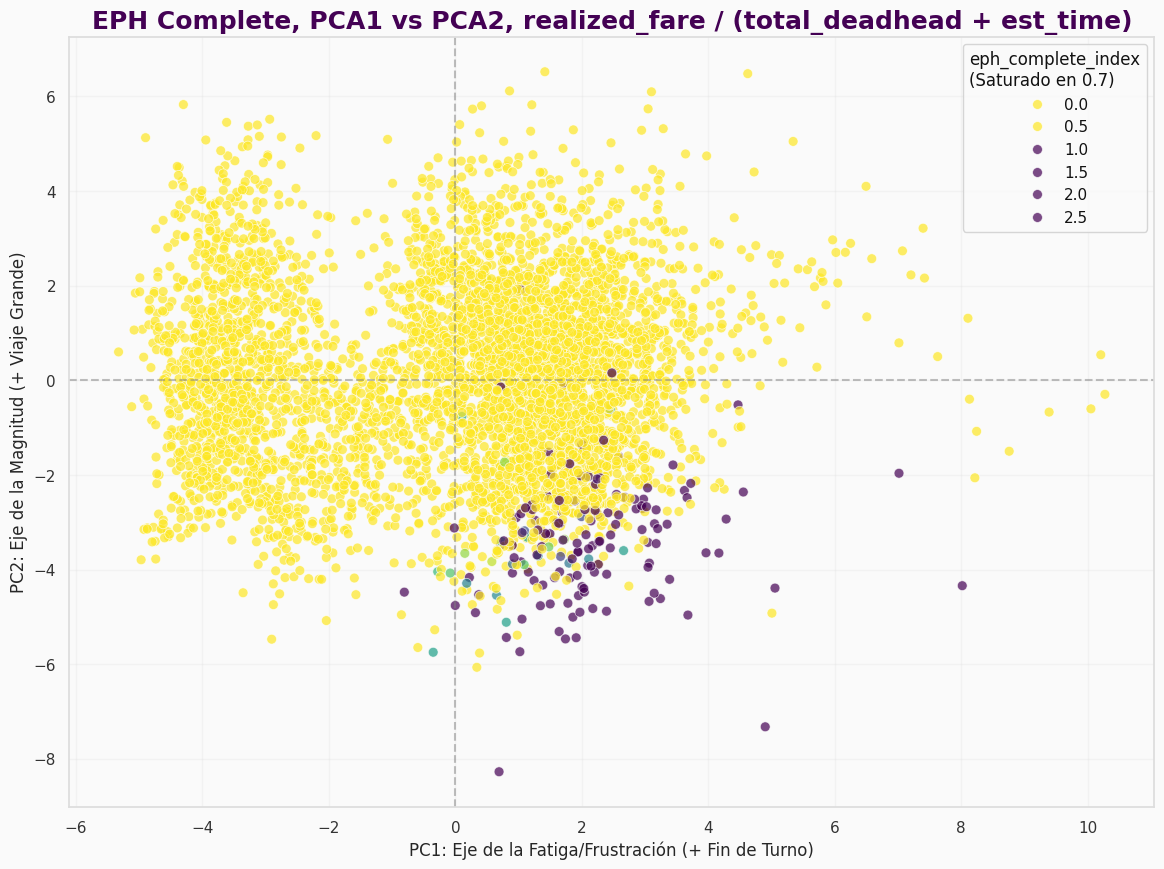

In [17]:
# ==============================================================================
# CELL 19: THE MARKET MAP (RECALIBRATED COLOR SCALE)
# ==============================================================================

# 1. Reuse df_pca, but add eph_complete_index_ML for the new hue
df_pca['eph_complete_index'] = df_grand['eph_complete_index_ML'].fillna(0).values

# 2. The Visualization with CLAMPED color scale
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='eph_complete_index',
    hue_norm=(0.6, 0.7), # <-- THE MAGIC IS HERE. Clamp the scale.
    palette='viridis_r', # High EPH = Yellow
    alpha=0.7,
    s=50
)
plt.xlabel("PC1: Eje de la Fatiga/Frustración (+ Fin de Turno)")
plt.ylabel("PC2: Eje de la Magnitud (+ Viaje Grande)")
plt.title("EPH Complete, PCA1 vs PCA2, realized_fare / (total_deadhead + est_time)", fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Adjust the legend to reflect the clamp
# Note: This is a bit of a hack as seaborn doesn't make this easy.
# We just need to make sure the user knows what they're seeing.
plt.legend(title='eph_complete_index\n(Saturado en 0.7)')

plt.show()

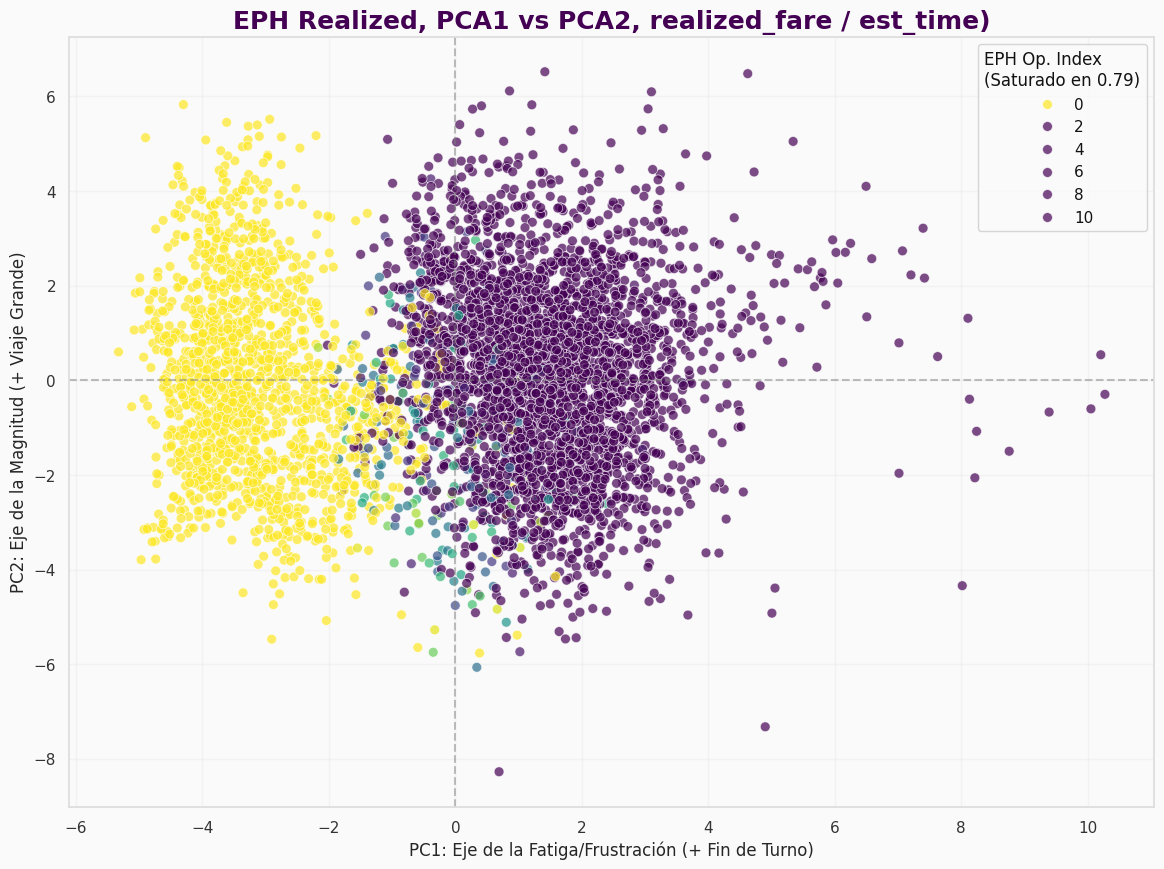

In [18]:
# ==============================================================================
# CELL 19: THE MARKET MAP (OPERATIONAL EFFICIENCY FOCUS)
# ==============================================================================

# 1. Agregamos eph_operational_index al DataFrame de PCA para el color
# Nota: Usamos eph_operational_index (la rentabilidad del viaje "puerta a puerta")
df_pca['eph_realized_index_ML'] = df_grand['eph_realized_index_ML'].fillna(0).values

# 2. La Visualización
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='eph_realized_index_ML',
    hue_norm=(0.6, 0.79), # <-- Mantengo tu escala: el amarillo brilla a partir de 0.7
    palette='viridis_r',
    alpha=0.7,
    s=50
)

plt.xlabel("PC1: Eje de la Fatiga/Frustración (+ Fin de Turno)")
plt.ylabel("PC2: Eje de la Magnitud (+ Viaje Grande)")
plt.title("EPH Realized, PCA1 vs PCA2, realized_fare / est_time)", fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Ajuste de leyenda
plt.legend(title='EPH Op. Index\n(Saturado en 0.79)')

plt.show()

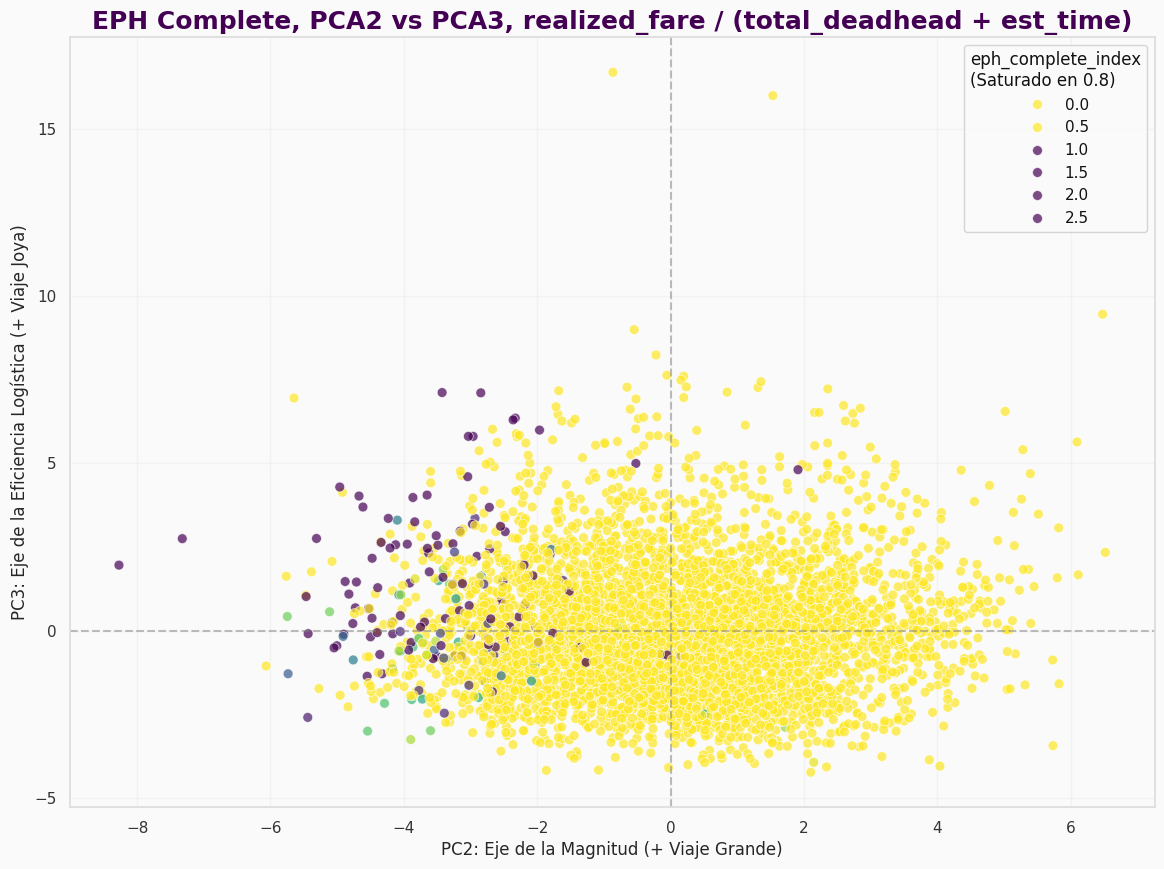

In [19]:
# ==============================================================================
# CELL 21: THE STRUCTURAL MAP (MAGNITUDE vs. LOGISTICS - RECALIBRATED)
# ==============================================================================

# 1. Reuse df_pca with 'eph_complete_index'

# 2. The Visualization
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca,
    x='PC2',
    y='PC3',
    hue='eph_complete_index',
    hue_norm=(0.6, 0.8),
    palette='viridis_r',
    alpha=0.7,
    s=50
)
plt.xlabel("PC2: Eje de la Magnitud (+ Viaje Grande)")
plt.ylabel("PC3: Eje de la Eficiencia Logística (+ Viaje Joya)")
plt.title("EPH Complete, PCA2 vs PCA3, realized_fare / (total_deadhead + est_time)", fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend(title='eph_complete_index\n(Saturado en 0.8)')

plt.show()

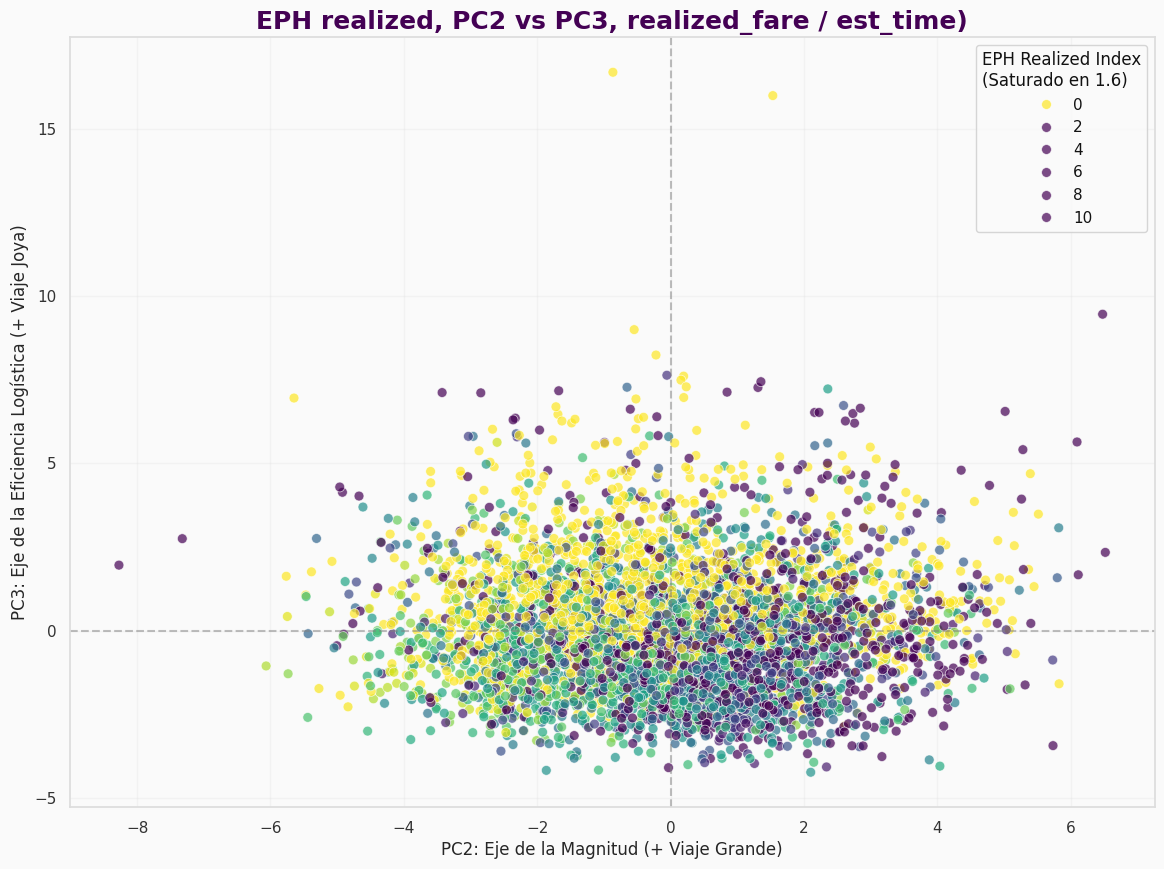

In [20]:
# ==============================================================================
# CELL 21: THE STRUCTURAL MAP (MAGNITUDE vs. LOGISTICS - REALIZED FOCUS)
# ==============================================================================

# 1. Agregamos eph_realized_index_ML al DataFrame de PCA para el color
# Nota: Esta es la métrica que ajusta la tarifa inicial por el spread histórico.
df_pca['eph_realized_index'] = df_grand['eph_realized_index_ML'].fillna(0).values

# 2. La Visualización
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca,
    x='PC2',
    y='PC3',
    hue='eph_realized_index',
    hue_norm=(0.6, 1.6), # Mantengo tu escala recalibrada
    palette='viridis_r',
    alpha=0.7,
    s=50
)

plt.xlabel("PC2: Eje de la Magnitud (+ Viaje Grande)")
plt.ylabel("PC3: Eje de la Eficiencia Logística (+ Viaje Joya)")
plt.title("EPH realized, PC2 vs PC3, realized_fare / est_time)", fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Ajuste de leyenda para reflejar la nueva métrica
plt.legend(title='EPH Realized Index\n(Saturado en 1.6)')

plt.show()